Ejercicio 1

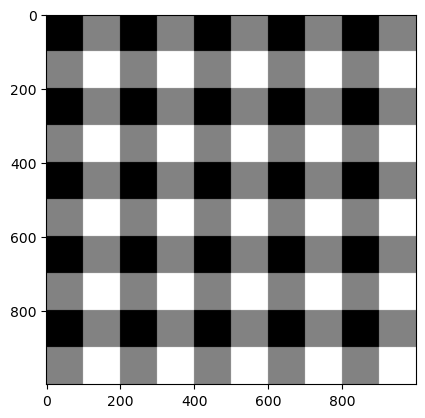

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tamaño_img = 100
R = np.ones((tamaño_img,tamaño_img))
G = np.ones((tamaño_img,tamaño_img))
B = np.ones((tamaño_img,tamaño_img))

blanco = np.dstack((R * 255,G * 255,B * 255))  
gris = np.dstack((R * 130,G * 130,B * 130)) 
negro = np.dstack((R * 0,G * 0,B * 0))     


superior = np.hstack((negro, gris))
inferior = np.hstack((gris, blanco))
#horizontal
imagenh1 = np.vstack((superior, inferior))
imagenh2 = np.hstack((imagenh1,imagenh1))
imagenh3 = np.hstack((imagenh2,imagenh1))
imagenh4 = np.hstack((imagenh3,imagenh2))
#vertical
imagenv3 = np.vstack((imagenh4,imagenh4))
imagenx1 = np.vstack((imagenv3,imagenv3))
imagenx2 = np.vstack((imagenx1,imagenh4))

plt.imshow(imagenx2.astype(int))
plt.show()

Ejercicio 2

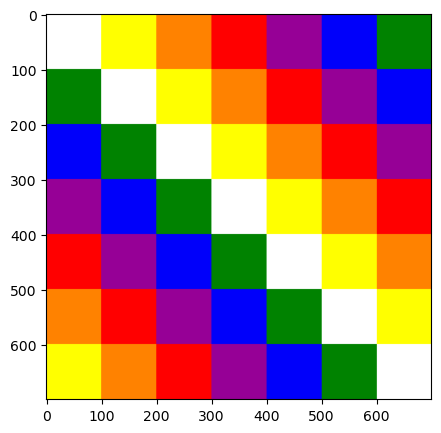

In [108]:
import matplotlib.pyplot as plt
import numpy as np

tamaño_img = 100
R = np.ones((tamaño_img,tamaño_img))
G = np.ones((tamaño_img,tamaño_img))
B = np.ones((tamaño_img,tamaño_img))

blanco = np.dstack((R * 255,G * 255,B * 255))  
amarillo = np.dstack((R * 255,G * 255,B * 0)) 
naranja = np.dstack((R * 255,G * 130,B * 0))     
rojo = np.dstack((R * 255,G * 0,B * 0))
morado = np.dstack((R * 150,G * 0,B * 150))
azul = np.dstack((R * 0,G * 0,B * 250))
verde = np.dstack((R * 0,G * 130,B * 0))

listColor1 = [blanco,amarillo,naranja,rojo,morado,azul,verde]
listColor2 = [verde,blanco,amarillo,naranja,rojo,morado,azul]
listColor3 = [azul,verde,blanco,amarillo,naranja,rojo,morado]
listColor4 = [morado,azul,verde,blanco,amarillo,naranja,rojo]
listColor5 = [rojo,morado,azul,verde,blanco,amarillo,naranja]
listColor6 = [naranja,rojo,morado,azul,verde,blanco,amarillo]
listColor7 = [amarillo,naranja,rojo,morado,azul,verde,blanco]

img1 = np.hstack(listColor1) 
img2 = np.hstack(listColor2)
img3 = np.hstack(listColor3)
img4 = np.hstack(listColor4)
img5 = np.hstack(listColor5) 
img6 = np.hstack(listColor6)
img7 = np.hstack(listColor7)
filas = [img1,img2,img3,img4,img5,img6,img7]

bandera = np.vstack(filas)

plt.imshow(bandera.astype(int))
plt.show()

Ejercicio 3

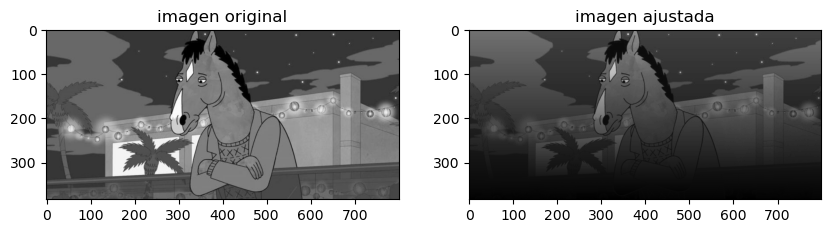

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen=cv2.imread('imagen1.jpg',0)

degrad_lineal= np.linspace(1,-0.1,imagen.shape[0])
mask1 = np.tile(degrad_lineal, (imagen.shape[1], 1)).T#crear mascara y dar vuelta al delineado
img_degradada = imagen * mask1

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title('imagen original')

plt.subplot(1,2,2)
plt.imshow(img_degradada,cmap='gray')
plt.title('imagen con degradado lineal')

plt.show()

Ejercicio 4

In [122]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg',0)
imagen=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

alto,ancho=img.shape[:2]
#crear mascara circular

mascara = np.zeros_like(img)
centro = (ancho//2,alto//2)
radio = 100
cv2.triangle(mascara,centro,radio,(255),-1)
img_mascara = cv2.bitwise_and(img,img,mask=mascara)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(imagen)
plt.title('imagen original')

plt.subplot(1,2,2)
plt.imshow(img_mascara,cmap='gray')
plt.title('imagen mascara')
plt.axis('off')


plt.show()

AttributeError: module 'cv2' has no attribute 'triangle'

Ejercicio 5

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def puntoInteres(imagen):

    #punto de interes
    plt.imshow(imagen[150:200,120:200,:])
    plt.show()
    #guardando de imagen
    img_cortada =imagen[50:65,20:35,:]
    plt.imsave('img_cortada.jpg',img_cortada)
    

def histogramas(imagen):
    seccionada = imagen
    color = ('r','g','b')
    for canal,col in enumerate(color):
        histograma = cv2.calcHist([seccionada*255],[canal],None,[256],[0,256])
        plt.plot(histograma,color=col)
        plt.xlim([0,256])
    plt.title('Histograma por canales')
    plt.show()

def solarizar(imagen, umbral):
    img_solarizada = np.where(imagen<umbral,imagen,255-imagen)
    return img_solarizada

def posterizar(imagen,nivel):
    factor = 255/nivel
    img_post = np.round((imagen/factor)*factor)
    return img_post.astype(np.uint8)

def dos_picos(imagen):
    hist = cv2.calcHist([imagen],[0],None,[256],[0,256])
    pico = np.array(hist)
    pico = pico.flatten()
    pico_dif = np.diff(pico)
    primer_pico = np.argmax(pico_dif[:128])
    segundo_pico = np.argmax(pico_dif[128:])+128
    umbral_2picos = int((primer_pico+segundo_pico)/2)
    return umbral_2picos

def mezclaDeTecnicas(imagen):
    umb_adap=cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,11,2)
    imgCol = cv2.applyColorMap(umb_adap,cv2.COLORMAP_INFERNO)
    return imgCol


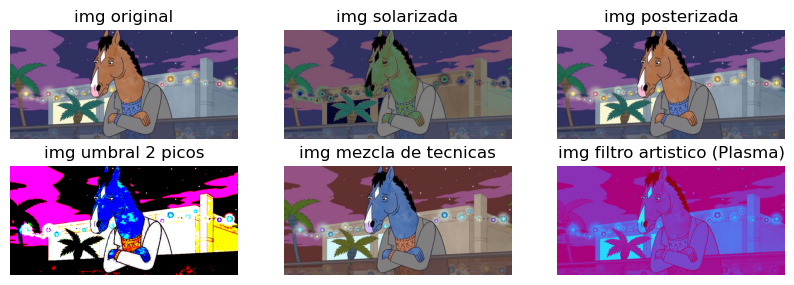

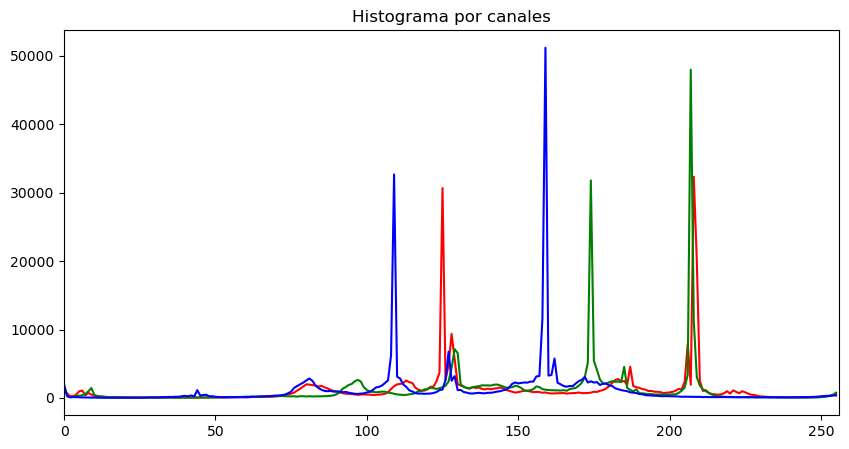

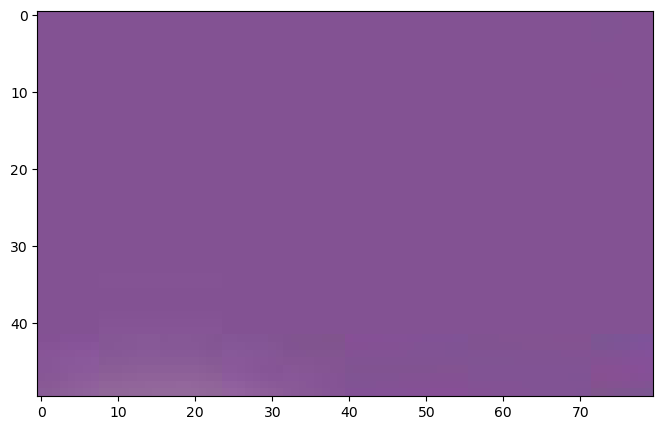

In [172]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen=cv2.imread('imagen1.jpg')
img_rgb = cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB)

img_solarizada = solarizar(img_rgb,127)
img_posterizada = posterizar(img_rgb,4)

umbral_2pic = dos_picos(imagen)
_,imagen_2pic = cv2.threshold(imagen,umbral_2pic,255,cv2.THRESH_BINARY)

img_filtro = cv2.applyColorMap(img_rgb,cv2.COLORMAP_PLASMA)
#img_mezcla = mezclaDeTecnicas(img_rgb)

plt.figure(figsize=(10,5))
plt.subplot(3,3,1)
plt.title('img original')
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3,3,2)
plt.title('img solarizada')
plt.imshow(img_solarizada)
plt.axis('off')

plt.subplot(3,3,3)
plt.title('img posterizada')
plt.imshow(img_posterizada)
plt.axis('off')

plt.subplot(1,3,1)
plt.title('img umbral 2 picos')
plt.imshow(imagen_2pic)
plt.axis('off')

plt.subplot(1,3,2)
plt.title('img mezcla de tecnicas')
plt.imshow(imagen)
plt.axis('off')

plt.subplot(1,3,3)
plt.title('img filtro artistico (Plasma)')
plt.imshow(img_filtro)
plt.axis('off')
plt.show()

histogramas(img_rgb)
puntoInteres(img_rgb)

In [160]:
plt.imsave('img_solarizada.jpg',img_solarizada)
plt.imsave('img_posterizada.jpg',img_posterizada)
plt.imsave('img_umbral2picos.jpg',imagen_2pic)
#plt.imsave('img_filtros.jpg',img_filtro)

Respuestas Teoria

1. Una imagen digital se refiere al conjunto de pixeles o bits que recrear en un entorno digital que recrea una imagen de la realidad
2. La profundidad del color es la cantidad o nivel que los colores pueden tener en una imagen
3. CMKY maneja los colores cyan, magenta , negro(Black) y el amarillo(Yellow) mientras que el RGB maneja los colores rojo, verde y azul